# "CUSTOMER SEGMENTATION VISUALIZATION AND ADVANCED ANALYSIS"

 PROJECT OVERVIEW - THE PROJECT AIMS TO ANALYZE CUSTOMER CHURN IN A TELECOMMUNICATIONS COMPANY AND DEVELOP PREDICTIVE M0DELS TO IDENTIFY AT-RISK CUSTOMERS. THE ULTIMATE GOAL IS TO PROVIDE ACTIONABLE INSIGHTS AND RECOMMENDATIONS TO REDUCE CHURN AND IMPROVE CUSTOMER RETENTION

In [2]:
import pandas as pd
import numpy as numpy

## TASK 1 - Understand dataset

In [3]:
df=pd.read_csv("Telco_Customer_Churn_Dataset.csv")
print(df.head(10))
df.dtypes #to know datatypes of each coloumn
df.info()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## TASK 2 - Data Cleaning

In [6]:
df.columns=df.columns.str.lower() #lowercase 
df.columns=df.columns.str.replace(" ","_") #replacing space with underscore
print(df.head(5))

   customerid  gender  seniorcitizen partner dependents  tenure phoneservice  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      multiplelines internetservice onlinesecurity  ... deviceprotection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  techsupport streamingtv streamingmovies        contract pape

In [7]:
df.duplicated().sum() #trying to find duplicates

np.int64(0)

In [8]:
# Check tenure for people with missing TotalCharges
print(df[df['totalcharges'].isnull()][['tenure', 'monthlycharges']])

      tenure  monthlycharges
488        0           52.55
753        0           20.25
936        0           80.85
1082       0           25.75
1340       0           56.05
3331       0           19.85
3826       0           25.35
4380       0           20.00
5218       0           19.70
6670       0           73.35
6754       0           61.90


In [9]:
# Fill missing values in TotalCharges with 0 because the tenure of those customer is 0 
df['totalcharges'] = df['totalcharges'].fillna(0)

## TASK 3 - Exploratory Data Analysis(EDA)

In [10]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [34]:
# Grouping by lifecycle stage
lifecycle_analysis = df.groupby('tenure_group')['Churn_Numeric'].mean().sort_values(ascending=False)

print("Churn Rate by Lifecycle Stage:")
print(lifecycle_analysis)

Churn Rate by Lifecycle Stage:
tenure_group
0-12 Months     0.474382
13-36 Months    0.255388
37+ Months      0.119294
Name: Churn_Numeric, dtype: float64


## TASK 4 : CUSTOMER SEGMENTATION VISUALIZATION

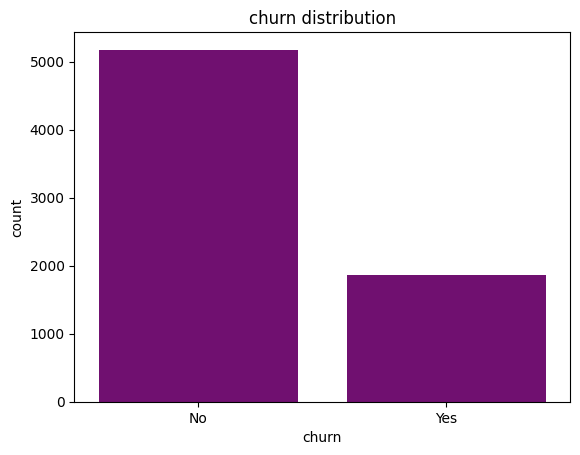

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='churn', data=df, color='purple')
plt.title("churn distribution")
plt.show()

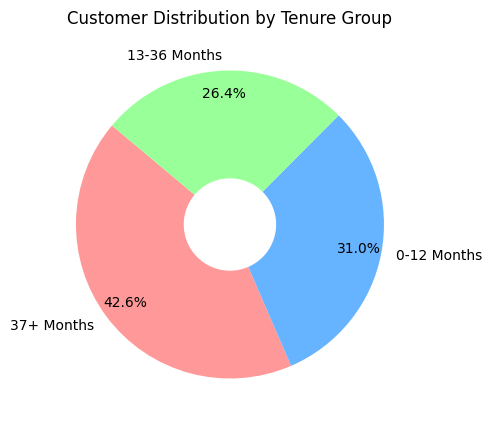

In [19]:
# Creating the categories
def categorize_tenure(t):
    if t <= 12:
        return '0-12 Months'
    elif t <= 36:
        return '13-36 Months'
    else:
        return '37+ Months'

df['tenure_group'] = df['tenure'].apply(categorize_tenure)

counts = df['tenure_group'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
        colors=['#ff9999','#66b3ff','#99ff99'], pctdistance=0.85)

# Draw a white circle in the middle to make it a donut
centre_circle = plt.Circle((0,0), 0.30, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Customer Distribution by Tenure Group")
plt.show()

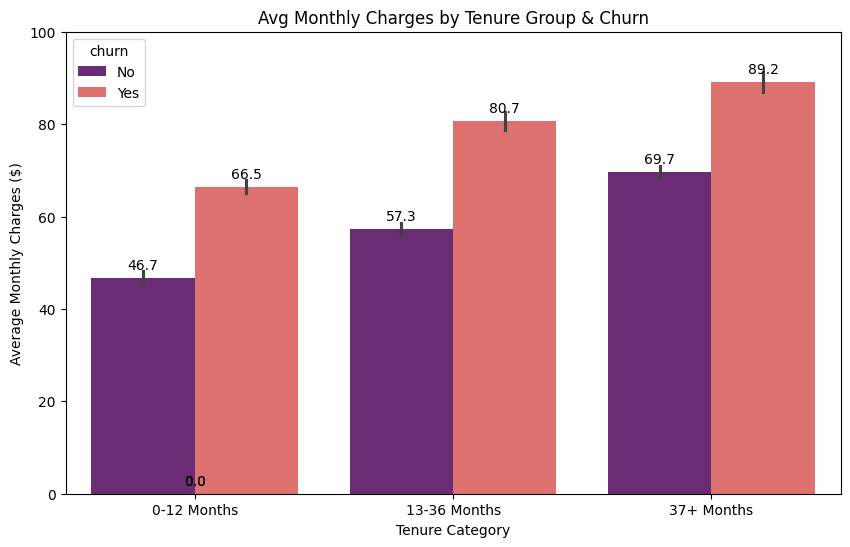

In [22]:
plt.figure(figsize=(10, 6))

# Creating the clustered bar chart
ax = sns.barplot(x='tenure_group', y='monthlycharges', hue='churn', data=df, palette='magma')

# Adding Annotations
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title("Avg Monthly Charges by Tenure Group & Churn")
plt.ylabel("Average Monthly Charges ($)")
plt.xlabel("Tenure Category")
plt.ylim(0, 100) # Adjust based on your data spread
plt.show()

## TASK 5- ADVANCED ANALYSIS

In [25]:
# Grouping by tenure to see mean charges and churn rate
df['churn_numeric']=df['churn'].map({"Yes":1 , "No":0})
tenure_stats = df.groupby('tenure').agg({
    'monthlycharges': 'mean',
    'totalcharges': 'mean',
    'churn_numeric': 'mean'  # This acts as the Churn Percentage
}).reset_index()

print(tenure_stats.head())

   tenure  monthlycharges  totalcharges  churn_numeric
0       0       41.418182      0.000000       0.000000
1       1       50.485808     50.485808       0.619902
2       2       57.206303    114.332353       0.516807
3       3       58.015000    174.690000       0.470000
4       4       57.432670    230.530682       0.471591


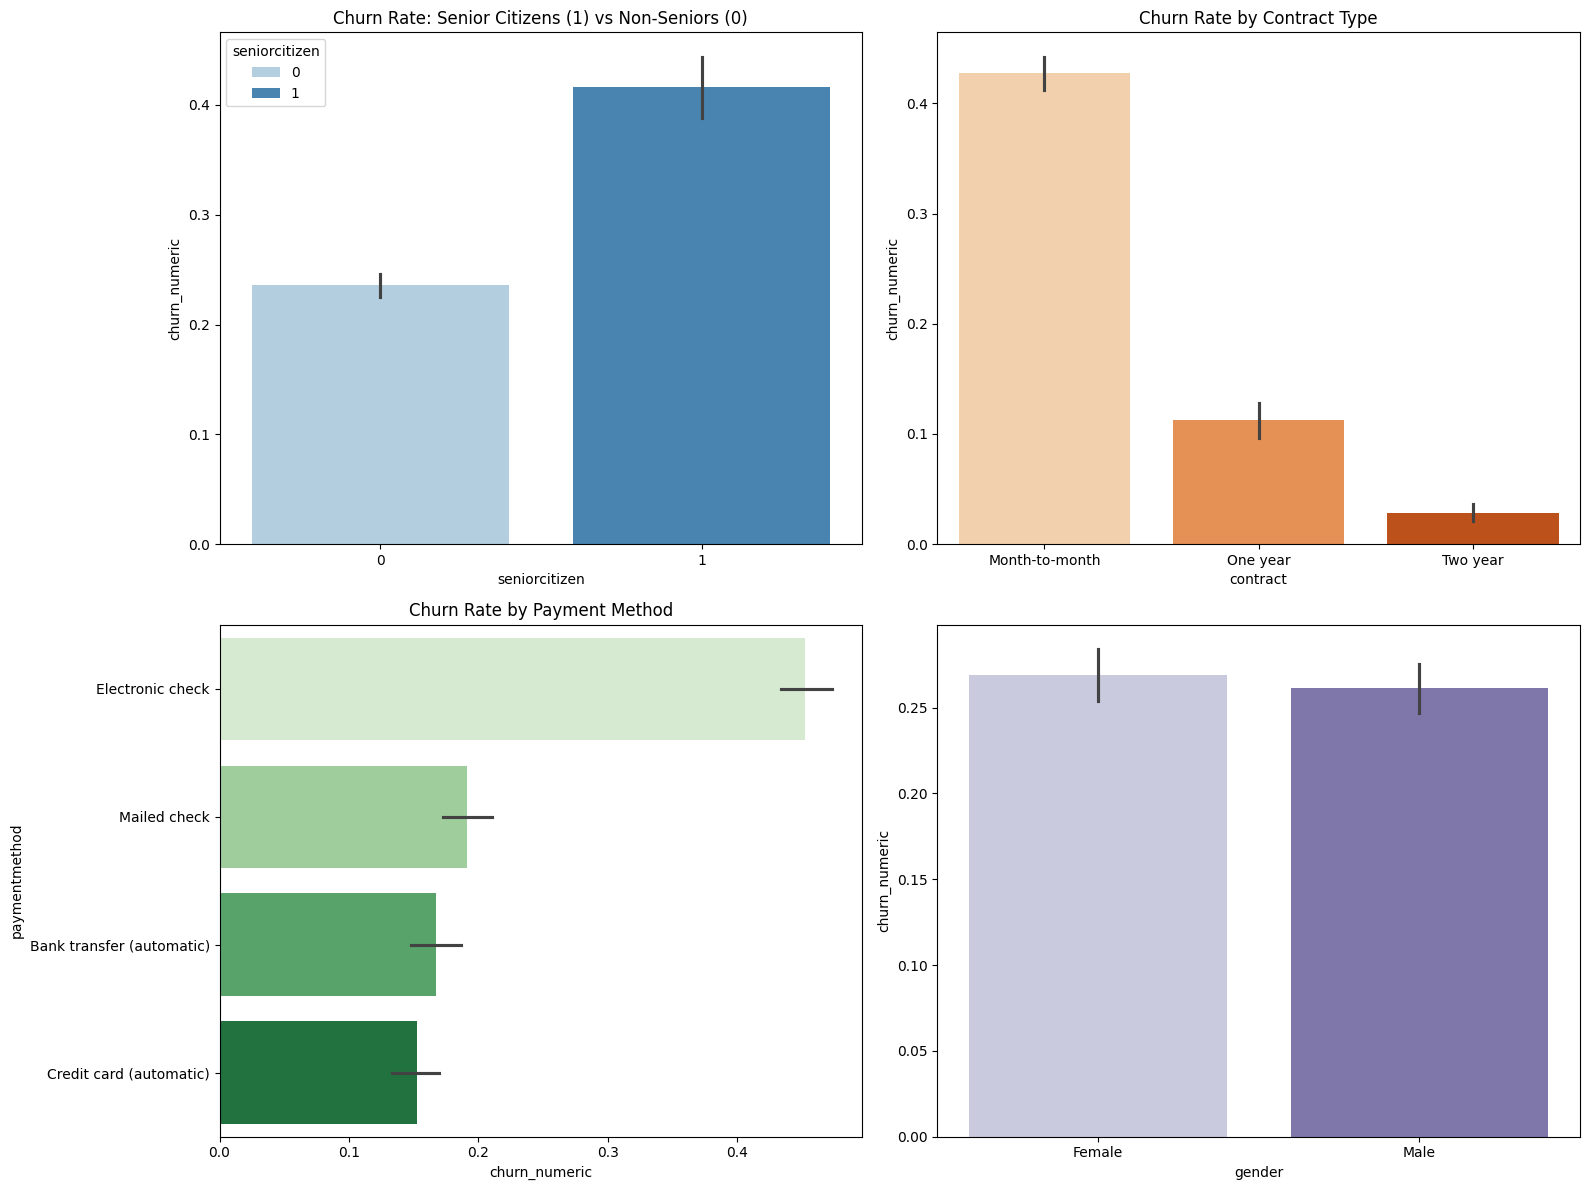

In [32]:
# Create a 2x2 grid for multiple analyses
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Churn by Senior Citizen Status
sns.barplot(x='seniorcitizen', y='churn_numeric',hue='seniorcitizen', data=df, ax=axes[0,0], palette='Blues')
axes[0,0].set_title('Churn Rate: Senior Citizens (1) vs Non-Seniors (0)')

# 2. Churn by Contract Type (Often the strongest predictor)
sns.barplot(x='contract', y='churn_numeric', hue='contract', data=df, ax=axes[0,1], palette='Oranges')
axes[0,1].set_title('Churn Rate by Contract Type')

# 3. Churn by Payment Method
sns.barplot(x='churn_numeric', y='paymentmethod', hue='paymentmethod', data=df, ax=axes[1,0], palette='Greens', orient='h')
axes[1,0].set_title('Churn Rate by Payment Method')

plt.tight_layout()
plt.show()

# KEY INSIGHTS

### 1.Contract Type Impact -charts likely show that Month-to-Month contracts have the highest churn.


### 2.Analysis reveals that customers in their first year (0-12 months) have a churn rate of 47.4%, which is roughly 4x higher than long-term customers (11.9%).

### 3.The advanced analysis of payment methods indicates that customers using Electronic Checks have significantly higher churn rates compared to those on automatic credit card or bank transfers.

### 4.Senior citizens (marked as 1 in your dataset) exhibit a higher churn rate compared to non-senior customers

### 5.Tenure Group - "Danger Zone" (0-12 Months): This group has the highest churn rate at 47.4%, Mid-Lifecycle Stability (13-36 Months) Churn drops significantly to 25.5% once a customer surpasses the one-year mark, The Loyalty Segment (37+ Months) Long-term customers are the most stable, with a low churn rate of only 11.9%

# RECOMMENDATIONS

### > Early Retention: Implement a proactive onboarding program during the first six months to resolve technical and billing issues early

### > Offer discounts or speed upgrades to move customers from month-to-month plans into long-term contracts

### > Targeted Senior Plans: Introduce lower-cost "Essential" plans and priority support lines specifically for senior citizens

### > Optimize Payments: Provide small monthly credits for customers who switch to Auto-Pay via bank transfer